# NB01: Data Extraction and Environment Classification

Build species-level AMR profiles with environment labels and phylogenetic context.

**Steps:**
1. Extract bakta_amr × gene_cluster (AMR clusters with species + core/aux)
2. Classify AMR mechanism from amr_gene/amr_product text
3. Build species environment classification (reuse amr_strain_variation + extend)
4. Get phylogenetic context (family level for controls)
5. Compute species-level AMR summaries
6. Data validation checkpoint

**Requires**: Spark (on BERDL JupyterHub)

**Outputs**: `data/species_amr_profiles.csv`, `data/species_environment.csv`, `data/genome_environment.csv`

In [1]:
import os
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)

_here = os.path.abspath('')
if os.path.basename(_here) == 'notebooks':
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))
elif os.path.exists(os.path.join(_here, 'projects', 'amr_environmental_resistome')):
    REPO = _here
else:
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))

PROJECT = os.path.join(REPO, 'projects', 'amr_environmental_resistome')
DATA = os.path.join(PROJECT, 'data')
FIGURES = os.path.join(PROJECT, 'figures')

os.makedirs(DATA, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

print(f'REPO: {REPO}')

REPO: /home/psdehal/pangenome_science/BERIL-research-observatory


## 1. Extract bakta_amr × gene_cluster

In [2]:
from berdl_notebook_utils.setup_spark_session import get_spark_session
spark = get_spark_session()

# bakta_amr is small (83K) — join to gene_cluster for species + core/aux
amr_clusters = spark.sql("""
    SELECT a.gene_cluster_id, gc.gtdb_species_clade_id,
           gc.is_core, gc.is_auxiliary, gc.is_singleton,
           a.amr_gene, a.amr_product, a.identity, a.accession
    FROM kbase_ke_pangenome.bakta_amr a
    JOIN kbase_ke_pangenome.gene_cluster gc ON a.gene_cluster_id = gc.gene_cluster_id
""").toPandas()

print(f'AMR clusters with species info: {len(amr_clusters):,}')
print(f'Unique species: {amr_clusters["gtdb_species_clade_id"].nunique():,}')
print(f'Core: {amr_clusters["is_core"].sum():,}, Auxiliary: {amr_clusters["is_auxiliary"].sum():,}, '
      f'Singleton: {amr_clusters["is_singleton"].sum():,}')

AMR clusters with species info: 83,008
Unique species: 14,723
Core: 25,172, Auxiliary: 57,836, Singleton: 29,937


## 2. Classify AMR mechanism

bakta_amr `method` is detection method (BLAST/HMM), NOT resistance mechanism.
Classify from amr_gene/amr_product using the classifier from amr_fitness_cost NB01.

In [3]:
# AMR class and mechanism patterns (from amr_fitness_cost NB01)
AMR_CLASS_PATTERNS = {
    'beta_lactam': [r'^bla', r'^ampC', r'^OXA', r'^CTX-M', r'^TEM', r'^SHV',
                    r'^KPC', r'^NDM', r'^VIM', r'^IMP'],
    'aminoglycoside': [r'^aac', r'^aph', r'^ant', r'^aad', r'^str[AB]',
                       r'^rmt[A-Z]', r'^armA'],
    'tetracycline': [r'^tet\(', r'^tet[A-Z]$', r'^otr'],
    'chloramphenicol': [r'^cat', r'^cml', r'^floR', r'^fexA'],
    'macrolide_lincosamide': [r'^erm', r'^msr', r'^mph', r'^mef', r'^lnu', r'^lin'],
    'glycopeptide': [r'^van[A-Z]$'],
    'rifampin': [r'^arr', r'^rox'],
    'fluoroquinolone': [r'^qnr', r'^oqx', r'^qep'],
    'sulfonamide': [r'^sul[0-9]', r'^dfr'],
    'polymyxin': [r'^mcr'],
    'fosfomycin': [r'^fos[A-Z]'],
    'efflux_rnd': [r'^acr[A-Z]', r'^mex[A-Z]', r'^ade[A-Z]', r'^opr[MN]',
                   r'^tolC', r'^emh[A-C]', r'^ttg[A-H]', r'^mdt[A-Z]', r'^mux[A-C]'],
    'efflux_mfs': [r'^emrD', r'^emrB', r'^emr[AE]', r'^norA', r'^norB', r'^lmr', r'^bmr'],
    'efflux_mate': [r'^mdt[KL]', r'^norM', r'^dinF'],
    'mercury': [r'^mer[A-Z]'],
    'arsenic': [r'^ars[A-Z]'],
    'copper': [r'^cop[A-Z]', r'^cue[A-Z]', r'^cus[A-Z]', r'^pco[A-Z]'],
    'silver': [r'^sil[A-Z]'],
    'chromate': [r'^chr[A-Z]'],
    'tellurite': [r'^ter[A-Z]', r'^teh[AB]'],
}

METAL_CLASSES = {'mercury', 'arsenic', 'copper', 'silver', 'chromate', 'tellurite'}
EFFLUX_CLASSES = {'efflux_rnd', 'efflux_mfs', 'efflux_mate'}

CLASS_TO_MECHANISM = {}
for cls in ['beta_lactam', 'aminoglycoside', 'chloramphenicol', 'fosfomycin']:
    CLASS_TO_MECHANISM[cls] = 'enzymatic_inactivation'
for cls in EFFLUX_CLASSES:
    CLASS_TO_MECHANISM[cls] = 'efflux'
CLASS_TO_MECHANISM['tetracycline'] = 'efflux'  # default; tet(M/O/Q/W) reclassified below
for cls in ['macrolide_lincosamide', 'glycopeptide', 'rifampin']:
    CLASS_TO_MECHANISM[cls] = 'target_modification'
for cls in METAL_CLASSES:
    CLASS_TO_MECHANISM[cls] = 'metal_resistance'
for cls in ['fluoroquinolone', 'sulfonamide', 'polymyxin']:
    CLASS_TO_MECHANISM[cls] = 'other'


def classify_amr_gene(gene_name):
    if pd.isna(gene_name) or gene_name == '':
        return 'unclassified', 'unknown'
    for amr_class, patterns in AMR_CLASS_PATTERNS.items():
        for pattern in patterns:
            if re.search(pattern, gene_name, re.IGNORECASE):
                return amr_class, CLASS_TO_MECHANISM.get(amr_class, 'other')
    return 'unclassified', 'unknown'


def reclassify_tet(gene_name, amr_class, mechanism):
    """Fix tetracycline: ribosomal protection proteins are target modification, not efflux."""
    if amr_class != 'tetracycline':
        return mechanism
    if pd.isna(gene_name):
        return mechanism
    g = gene_name.upper()
    # Ribosomal protection proteins
    if any(x in g for x in ['TET(M)', 'TET(O)', 'TET(Q)', 'TET(W)', 'TET(S)',
                              'TETM', 'TETO', 'TETQ', 'TETW', 'TETS']):
        return 'target_modification'
    return 'efflux'


def classify_amr_product(product):
    if pd.isna(product) or product == '':
        return 'unclassified', 'unknown'
    p = product.lower()
    if 'beta-lactamase' in p: return 'beta_lactam', 'enzymatic_inactivation'
    if 'aminoglycoside' in p: return 'aminoglycoside', 'enzymatic_inactivation'
    if 'chloramphenicol' in p: return 'chloramphenicol', 'enzymatic_inactivation'
    if 'tetracycline' in p and ('efflux' in p or 'resistance' in p): return 'tetracycline', 'efflux'
    if 'macrolide' in p or 'erythromycin' in p: return 'macrolide_lincosamide', 'target_modification'
    if 'vancomycin' in p: return 'glycopeptide', 'target_modification'
    if 'multidrug' in p and ('efflux' in p or 'resistance' in p): return 'efflux_rnd', 'efflux'
    if 'mercury' in p: return 'mercury', 'metal_resistance'
    if 'arsenic' in p or 'arsenate' in p: return 'arsenic', 'metal_resistance'
    if 'copper' in p and 'resistance' in p: return 'copper', 'metal_resistance'
    if 'chromate' in p and 'resistance' in p: return 'chromate', 'metal_resistance'
    if 'tellurite' in p: return 'tellurite', 'metal_resistance'
    if 'fosfomycin' in p: return 'fosfomycin', 'enzymatic_inactivation'
    if 'antibiotic' in p and ('efflux' in p or 'resistance' in p): return 'efflux_rnd', 'efflux'
    if 'efflux' in p and ('rnd' in p or 'pump' in p or 'drug' in p): return 'efflux_rnd', 'efflux'
    return 'unclassified', 'unknown'


# Classify: gene name first, product fallback
amr_clusters[['amr_class', 'amr_mechanism']] = amr_clusters['amr_gene'].apply(
    lambda g: pd.Series(classify_amr_gene(g)))

mask = amr_clusters['amr_class'] == 'unclassified'
if mask.any():
    amr_clusters.loc[mask, ['amr_class', 'amr_mechanism']] = amr_clusters.loc[mask, 'amr_product'].apply(
        lambda p: pd.Series(classify_amr_product(p)))

# Reclassify tetracycline ribosomal protection as target_modification
amr_clusters['amr_mechanism'] = amr_clusters.apply(
    lambda r: reclassify_tet(r['amr_gene'], r['amr_class'], r['amr_mechanism']), axis=1)

amr_clusters['resistance_type'] = amr_clusters['amr_class'].apply(
    lambda c: 'metal' if c in METAL_CLASSES else 'antibiotic')

print(f'Mechanism distribution:')
print(amr_clusters['amr_mechanism'].value_counts().to_string())
print(f'\nResistance type:')
print(amr_clusters['resistance_type'].value_counts().to_string())

Mechanism distribution:
amr_mechanism
enzymatic_inactivation    26220
metal_resistance          22223
target_modification       12916
efflux                     3375
other                      2724

Resistance type:
resistance_type
antibiotic    60785
metal         22223


## 3. Species environment classification

In [4]:
# Try to reuse amr_strain_variation species-level classification
asv_meta_path = os.path.join(REPO, 'projects', 'amr_strain_variation', 'data', 'genome_metadata.csv')

if os.path.exists(asv_meta_path):
    asv_meta = pd.read_csv(asv_meta_path)
    print(f'Loaded amr_strain_variation metadata: {len(asv_meta)} rows')
    print(f'Columns: {list(asv_meta.columns)}')
    # Check what environment column exists
    env_cols = [c for c in asv_meta.columns if 'env' in c.lower() or 'habitat' in c.lower() or 'niche' in c.lower()]
    print(f'Environment columns: {env_cols}')
    if env_cols:
        print(f'\nEnvironment distribution:')
        print(asv_meta[env_cols[0]].value_counts().to_string())
else:
    print(f'amr_strain_variation metadata not found at {asv_meta_path}')
    print('Will derive environment from ncbi_env directly')

amr_strain_variation metadata not found at /home/psdehal/pangenome_science/BERIL-research-observatory/projects/amr_strain_variation/data/genome_metadata.csv
Will derive environment from ncbi_env directly


In [5]:
# Extract per-genome environment from ncbi_env (EAV format)
# Join: genome.ncbi_biosample_id -> ncbi_env.accession
print('Extracting per-genome environment from ncbi_env...')

genome_env = spark.sql("""
    SELECT g.genome_id, g.gtdb_species_clade_id,
           MAX(CASE WHEN n.harmonized_name = 'isolation_source' THEN n.content END) AS isolation_source,
           MAX(CASE WHEN n.harmonized_name = 'host' THEN n.content END) AS host,
           MAX(CASE WHEN n.harmonized_name = 'geo_loc_name' THEN n.content END) AS geo_loc_name
    FROM kbase_ke_pangenome.genome g
    JOIN kbase_ke_pangenome.ncbi_env n ON g.ncbi_biosample_id = n.accession
    WHERE n.harmonized_name IN ('isolation_source', 'host', 'geo_loc_name')
    GROUP BY g.genome_id, g.gtdb_species_clade_id
""").toPandas()

print(f'Genomes with ncbi_env data: {len(genome_env):,}')
print(f'With isolation_source: {genome_env["isolation_source"].notna().sum():,}')
print(f'With host: {genome_env["host"].notna().sum():,}')

Extracting per-genome environment from ncbi_env...


Genomes with ncbi_env data: 280,337
With isolation_source: 245,717
With host: 170,851


In [6]:
# Classify environment from isolation_source and host keywords
# (rule-based approach matching amr_strain_variation methodology)

def classify_environment(isolation_source, host):
    """Classify a genome into environment categories from NCBI metadata."""
    iso = str(isolation_source).lower() if pd.notna(isolation_source) else ''
    h = str(host).lower() if pd.notna(host) else ''
    
    # Clinical
    if any(kw in iso for kw in ['clinical', 'patient', 'hospital', 'blood', 'sputum',
                                 'urine', 'wound', 'abscess', 'biopsy', 'swab']):
        return 'clinical'
    if any(kw in h for kw in ['homo sapiens', 'human']):
        if any(kw in iso for kw in ['stool', 'feces', 'gut', 'intestin', 'colon', 'rectal']):
            return 'human_gut'
        return 'clinical'
    
    # Host-associated (non-human)
    if h and h not in ['missing', 'not collected', 'not applicable', 'nan', 'unknown', 'none']:
        return 'host_associated'
    if any(kw in iso for kw in ['animal', 'bovine', 'poultry', 'chicken', 'pig',
                                 'cattle', 'fish', 'insect', 'plant', 'root', 'leaf',
                                 'rhizosphere', 'endophyte', 'phyllosphere']):
        return 'host_associated'
    
    # Soil
    if any(kw in iso for kw in ['soil', 'sediment', 'rhizosphere', 'compost',
                                 'agricultural', 'farm', 'mine', 'terrestrial']):
        return 'soil'
    
    # Aquatic
    if any(kw in iso for kw in ['water', 'sea', 'ocean', 'river', 'lake', 'marine',
                                 'freshwater', 'wastewater', 'aquatic', 'estuar',
                                 'groundwater', 'stream', 'pond', 'wetland']):
        return 'aquatic'
    
    # Other environmental
    if any(kw in iso for kw in ['air', 'food', 'milk', 'cheese', 'ferment',
                                 'biofilm', 'activated sludge', 'bioreactor']):
        return 'other_environmental'
    
    if iso and iso not in ['missing', 'not collected', 'not applicable', 'nan', 'unknown', 'none', '']:
        return 'other_environmental'
    
    return 'unknown'


genome_env['environment'] = genome_env.apply(
    lambda r: classify_environment(r['isolation_source'], r['host']), axis=1)

print(f'Per-genome environment classification:')
print(genome_env['environment'].value_counts().to_string())
print(f'\nClassified: {(genome_env["environment"] != "unknown").sum():,} / {len(genome_env):,} '
      f'({(genome_env["environment"] != "unknown").mean()*100:.1f}%)')

Per-genome environment classification:
environment
clinical               95789
host_associated        60916
other_environmental    45543
aquatic                31233
unknown                18282
soil                   14340
human_gut              14234

Classified: 262,055 / 280,337 (93.5%)


In [7]:
# Species-level majority-vote environment classification
# For each species, assign the most common environment among its classified genomes

classified = genome_env[genome_env['environment'] != 'unknown']

species_env_votes = classified.groupby(['gtdb_species_clade_id', 'environment']).size().reset_index(name='count')
species_totals = classified.groupby('gtdb_species_clade_id')['environment'].count().reset_index(name='n_classified')

# Get majority environment per species
idx = species_env_votes.groupby('gtdb_species_clade_id')['count'].idxmax()
species_majority = species_env_votes.loc[idx][['gtdb_species_clade_id', 'environment', 'count']].copy()
species_majority = species_majority.merge(species_totals, on='gtdb_species_clade_id')
species_majority['majority_frac'] = species_majority['count'] / species_majority['n_classified']
species_majority.columns = ['gtdb_species_clade_id', 'species_environment', 'majority_count',
                             'n_classified_genomes', 'majority_frac']

print(f'Species with environment classification: {len(species_majority):,}')
print(f'\nSpecies-level environment distribution:')
print(species_majority['species_environment'].value_counts().to_string())
print(f'\nMajority fraction: mean={species_majority["majority_frac"].mean():.2f}, '
      f'median={species_majority["majority_frac"].median():.2f}')

Species with environment classification: 26,715

Species-level environment distribution:
species_environment
host_associated        8382
aquatic                7144
other_environmental    6091
soil                   3149
clinical               1500
human_gut               449

Majority fraction: mean=0.87, median=1.00


## 4. Phylogenetic context

In [8]:
# Get taxonomy per species (use one genome per species)
taxonomy = spark.sql("""
    SELECT genome_id, phylum, class, `order`, family, genus
    FROM kbase_ke_pangenome.gtdb_taxonomy_r214v1
""").toPandas()

print(f'Taxonomy records: {len(taxonomy):,}')

# Map genome to species
genome_species = spark.sql("""
    SELECT genome_id, gtdb_species_clade_id
    FROM kbase_ke_pangenome.genome
""").toPandas()

# Merge and take one per species
tax_with_species = taxonomy.merge(genome_species, on='genome_id')
species_taxonomy = tax_with_species.drop_duplicates('gtdb_species_clade_id', keep='first')
species_taxonomy = species_taxonomy[['gtdb_species_clade_id', 'phylum', 'class', 'order', 'family', 'genus']]

print(f'Species with taxonomy: {len(species_taxonomy):,}')
print(f'Unique phyla: {species_taxonomy["phylum"].nunique()}')
print(f'Unique families: {species_taxonomy["family"].nunique()}')

Taxonomy records: 293,059


Species with taxonomy: 27,690
Unique phyla: 142
Unique families: 2464


## 5. Build species-level AMR summaries

In [9]:
# Species-level AMR summary
species_amr = amr_clusters.groupby('gtdb_species_clade_id').agg(
    n_amr_clusters=('gene_cluster_id', 'nunique'),
    n_core_amr=('is_core', 'sum'),
    n_aux_amr=('is_auxiliary', lambda x: (x & ~amr_clusters.loc[x.index, 'is_singleton']).sum()),
    n_singleton_amr=('is_singleton', 'sum'),
    n_efflux=('amr_mechanism', lambda x: (x == 'efflux').sum()),
    n_enzymatic=('amr_mechanism', lambda x: (x == 'enzymatic_inactivation').sum()),
    n_metal=('amr_mechanism', lambda x: (x == 'metal_resistance').sum()),
    n_target_mod=('amr_mechanism', lambda x: (x == 'target_modification').sum()),
    n_other_mech=('amr_mechanism', lambda x: x.isin(['other', 'unknown']).sum()),
    n_unclassified=('amr_mechanism', lambda x: (~x.isin(['efflux', 'enzymatic_inactivation', 'metal_resistance', 'target_modification', 'other', 'unknown'])).sum()),
).reset_index()

species_amr['pct_core_amr'] = species_amr['n_core_amr'] / species_amr['n_amr_clusters'] * 100
species_amr['pct_accessory_amr'] = (1 - species_amr['n_core_amr'] / species_amr['n_amr_clusters']) * 100

print(f'Species with AMR data: {len(species_amr):,}')
print(f'AMR clusters per species: mean={species_amr["n_amr_clusters"].mean():.1f}, '
      f'median={species_amr["n_amr_clusters"].median():.0f}, '
      f'max={species_amr["n_amr_clusters"].max()}')

Species with AMR data: 14,723
AMR clusters per species: mean=5.6, median=2, max=1115


In [10]:
# Merge everything: AMR + environment + taxonomy
species_full = species_amr.merge(species_majority, on='gtdb_species_clade_id', how='left')
species_full = species_full.merge(species_taxonomy, on='gtdb_species_clade_id', how='left')

# Get genome counts from pangenome table
pangenome_stats = spark.sql("""
    SELECT gtdb_species_clade_id, CAST(no_genomes AS INT) as no_genomes
    FROM kbase_ke_pangenome.pangenome
""").toPandas()
species_full = species_full.merge(pangenome_stats, on='gtdb_species_clade_id', how='left')

print(f'Species with AMR + env + taxonomy: {len(species_full):,}')
print(f'With environment: {species_full["species_environment"].notna().sum():,} '
      f'({species_full["species_environment"].notna().mean()*100:.1f}%)')
print(f'With taxonomy: {species_full["phylum"].notna().sum():,}')

# Save
species_full.to_csv(os.path.join(DATA, 'species_amr_profiles.csv'), index=False)
species_majority.to_csv(os.path.join(DATA, 'species_environment.csv'), index=False)
genome_env.to_csv(os.path.join(DATA, 'genome_environment.csv'), index=False)
print(f'\nSaved species_amr_profiles.csv, species_environment.csv, genome_environment.csv')

Species with AMR + env + taxonomy: 14,723
With environment: 13,981 (95.0%)
With taxonomy: 14,723



Saved species_amr_profiles.csv, species_environment.csv, genome_environment.csv


## 6. Data validation checkpoint

In [11]:
print('=== DATA VALIDATION CHECKPOINT ===')
print()

# (a) Species with >=1 AMR cluster
print(f'(a) Species with >=1 AMR cluster: {len(species_amr):,} / ~27,700')

# (b) Total AMR clusters matches expected
total_clusters = amr_clusters['gene_cluster_id'].nunique()
print(f'(b) Unique AMR clusters: {total_clusters:,} (expected ~83K)')

# (c) Environment labels joined correctly
env_coverage = species_full['species_environment'].notna().mean()
print(f'(c) Environment coverage: {env_coverage*100:.1f}%')

# (d) Sample sizes per environment
print(f'(d) Species per environment:')
env_counts = species_full['species_environment'].value_counts(dropna=False)
for env, count in env_counts.items():
    label = env if pd.notna(env) else 'NO_ENV_DATA'
    print(f'    {label:25s}: {count:6,}')

# (e) Qualifying species for NB03 (>=5 genomes in each of >=2 environments)
print(f'\n(e) NB03 qualifying species (>=5 genomes in >=2 environments):')
classified_genomes = genome_env[genome_env['environment'] != 'unknown']
env_per_species = classified_genomes.groupby(['gtdb_species_clade_id', 'environment']).size().reset_index(name='n')
env_per_species_5 = env_per_species[env_per_species['n'] >= 5]
species_multi_env = env_per_species_5.groupby('gtdb_species_clade_id').size()
qualifying = species_multi_env[species_multi_env >= 2]
print(f'    Species with >=5 genomes in >=2 environments: {len(qualifying)}')
if len(qualifying) > 0:
    for sp in qualifying.head(10).index:
        envs = env_per_species_5[env_per_species_5['gtdb_species_clade_id'] == sp]
        env_str = ', '.join(f'{r["environment"]}={r["n"]}' for _, r in envs.iterrows())
        print(f'      {sp[:60]:60s} {env_str}')
    if len(qualifying) > 10:
        print(f'      ... and {len(qualifying)-10} more')

=== DATA VALIDATION CHECKPOINT ===

(a) Species with >=1 AMR cluster: 14,723 / ~27,700
(b) Unique AMR clusters: 82,908 (expected ~83K)
(c) Environment coverage: 95.0%
(d) Species per environment:
    host_associated          :  4,788
    other_environmental      :  3,195
    aquatic                  :  2,543
    soil                     :  1,905
    clinical                 :  1,186
    NO_ENV_DATA              :    742
    human_gut                :    364

(e) NB03 qualifying species (>=5 genomes in >=2 environments):
    Species with >=5 genomes in >=2 environments: 884
      s__Acd1_sp000389735--GB_GCA_000389735.1                      aquatic=7, soil=8
      s__Acetatifactor_intestinalis--RS_GCF_009695995.1            host_associated=6, human_gut=26, other_environmental=26
      s__Acetatifactor_sp900066565--GB_GCA_003584705.1             human_gut=24, other_environmental=17
      s__Achromobacter_insolitus--RS_GCF_002209555.1               host_associated=6, other_environmental=6


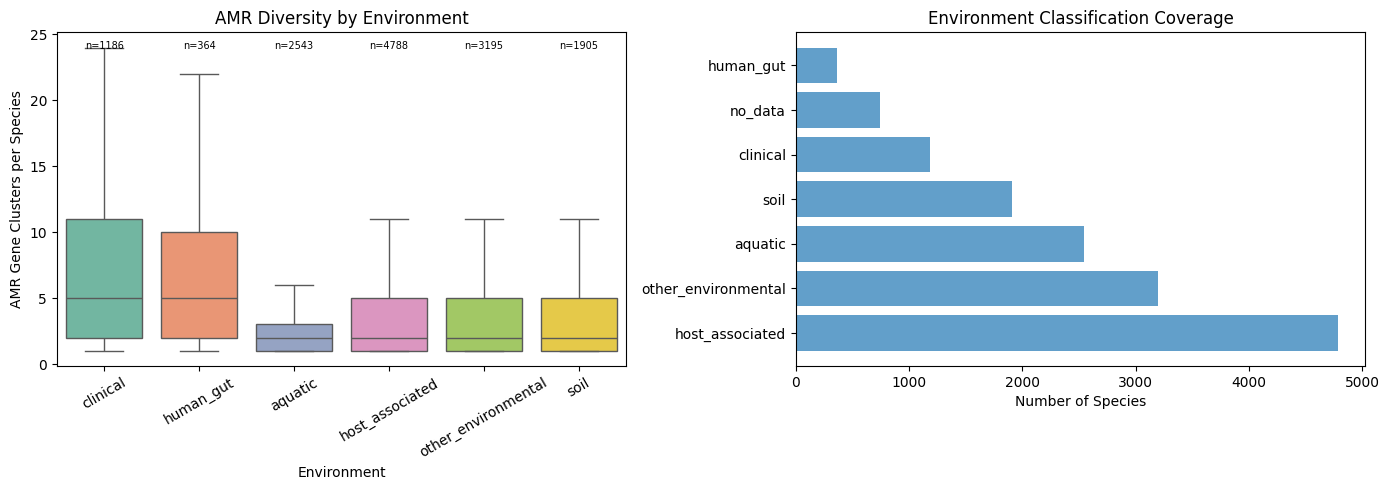

Saved to figures/nb01_validation.png


In [12]:
# Validation figures
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: AMR count distribution by environment
ax = axes[0]
plot_data = species_full[species_full['species_environment'].notna()]
env_order = plot_data.groupby('species_environment')['n_amr_clusters'].median().sort_values(ascending=False).index
sns.boxplot(data=plot_data, x='species_environment', y='n_amr_clusters',
            order=env_order, ax=ax, showfliers=False, palette='Set2')
ax.set_xlabel('Environment')
ax.set_ylabel('AMR Gene Clusters per Species')
ax.set_title('AMR Diversity by Environment')
ax.tick_params(axis='x', rotation=30)
for i, env in enumerate(env_order):
    n = len(plot_data[plot_data['species_environment'] == env])
    ax.text(i, ax.get_ylim()[1]*0.95, f'n={n}', ha='center', fontsize=7)

# Right: environment coverage
ax = axes[1]
env_counts_clean = species_full['species_environment'].fillna('no_data').value_counts()
ax.barh(range(len(env_counts_clean)), env_counts_clean.values, color='tab:blue', alpha=0.7)
ax.set_yticks(range(len(env_counts_clean)))
ax.set_yticklabels(env_counts_clean.index)
ax.set_xlabel('Number of Species')
ax.set_title('Environment Classification Coverage')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'nb01_validation.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved to figures/nb01_validation.png')

In [13]:
print('=== NB01 Summary ===')
print(f'AMR clusters extracted: {total_clusters:,} across {len(species_amr):,} species')
print(f'Environment classified: {species_full["species_environment"].notna().sum():,} species '
      f'({env_coverage*100:.1f}%)')
print(f'Taxonomy available: {species_full["family"].notna().sum():,} species')
print(f'NB03 qualifying species: {len(qualifying)}')
print(f'\nReady for NB02 (species-level resistome vs environment)')

=== NB01 Summary ===
AMR clusters extracted: 82,908 across 14,723 species
Environment classified: 13,981 species (95.0%)
Taxonomy available: 14,723 species
NB03 qualifying species: 884

Ready for NB02 (species-level resistome vs environment)
